# Substructuring using Craig-Bampton Superelements from Sierra/SD

This example will demonstrate the capabilities in SDynPy for working with
superelements from Sierra/SD.  We will generate a small toy problem that we
can use to demonstrate the functionality.  We will then run Sierra to generate
output, load it into SDynPy, and combine the components together.

## Setting up the Problem

(drop:cbr_model_downloads)=
:::{dropdown} Model Downloads
The files used by this example can be downloaded here.

The website may change the names of the download files, so they should be renamed to their original names shown on this page to be correctly loaded into the code used by this example.  The code in this example assumes these files are downloaded into the current working directory.

(tab:cbr_mesh_files)=
| All Mesh Files |
| ----------|
| {download}`../assets/cubit_input_file.py` |

(tab:cbr_input_files)=
| Model Name | Sierra/SD Input Files |
| ----------| ----------------------|
|Block 1 | {download}`../assets/block_1.inp`|
|Block 2| {download}`../assets/block_2.inp`|
|Truth | {download}`../assets/block_all.inp`|

(tab:cbr_results_files)=
| Model Name | CBR Exodus File | CBR Superelement File | Eigensolution |
| -----------| ------------| --------------------- | ---------------|
| Block 1 | {download}`../assets/block_1-cbr.exo` | {download}`../assets/block_1-cbr.nc4` | {download}`../assets/block_1-eig.exo` |
| Block 2 | {download}`../assets/block_2-cbr.exo` | {download}`../assets/block_2-cbr.nc4` | {download}`../assets/block_2-eig.exo` |
| Truth | -- | -- | {download}`../assets/block_all-eig.exo` |
:::

We will first use the Cubit software to generate a mesh for the finite element
analysis.  We will create a small spaceship-looking model consisting of 4
rectangular sections.  The attached input file [`cubit_input_file.py`](#tab:cbr_mesh_files) in the [Model Downloads](#drop:cbr_model_downloads)
can be executed using Cubit's Python interface to create the model.

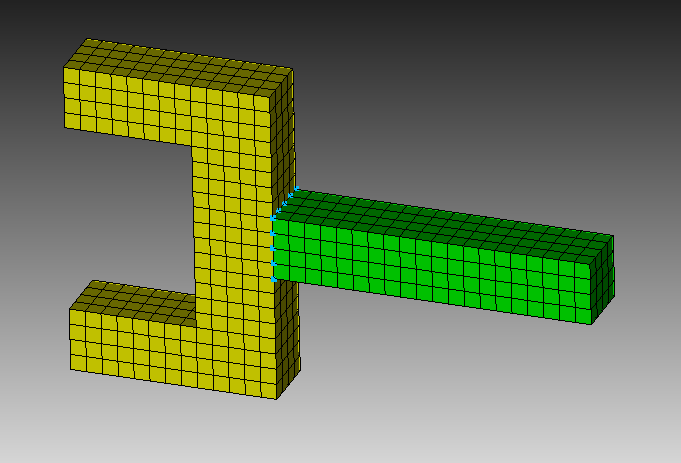

This model contains two element blocks, block 1 and block 2, which are the 
'nose' and the 'thrusters' of the spaceship, respectively.  The model also
contains a single nodeset 1 which specifies the boundary nodes that will
be retained in the Craig Bampton Substructuring.  The attached Cubit input file
will generate three exodus files.  One containing element block 1 ``block_1.exo``,
a second containing element block 2 ``block_2.exo``, and a third containing
both element blocks 1 and 2 ``block_all.exo``, which is to be used for truth data.

Input files are then set up for the Sierra/SD code. In each input file, there
will be an Eigensolution ``eigen`` and a Craig-Bampton Reduction ``cbr``
solution.  The ``cbr`` solution will produce the superelement that will later
be used for substructuring, and the ``eigen`` solution will compute the modes
of the full model, which can be compared to the reduced ``cbr`` model to check
convergence.  A 'truth' input file will also be generated to run the full model;
this will only contain an ``eigen`` solution as no substructuring will be
performed with this model.  [Input Files](#tab:cbr_input_files) can be downloaded from the [Model Downloads](#drop:cbr_model_downloads).

When run, each of the two ``cbr`` analyses will output a superelement file
``block_<i>-cbr.nc4`` as well as an Exodus file ``block_<i>-cbr.exo``.
The superelement ``.nc4`` file will contain the reduced mass and stiffness
matrices (damping also, though this is zero) as well as a map denoting which
reduction degrees of freedom correspond to physical degres of freedom and which
correspond to fixed base modes.  The Exodus file contains the Craig-Bampton
transformation shapes, meaning its shapes are the fixed interface mode shapes
and the constraint mode shapes.  The shapes in this file transform the reduced
degrees of freedom back to the physical degrees of freedom.  Each analysis will
also output an Exodus file called ``block_<i>-eig.exo``.  This will contain the
eigensolution computed from the full mass and stiffness matrices, which can be
used to check convergence of the reduce model.
The 'truth' analysis in ``block_all.inp`` will output only an Exodus file
``block_all-eig.exo`` which contains the eigensolution computed from the full
combined system models, which will be treated as truth data for this work.
The [results files](#tab:cbr_results_files) can be downloaded from the [Model Downloads](#drop:cbr_model_downloads).

The code in this script assumes that the files have been downloaded into the current working directory
and have the same names as shown in [Model Downloads](#drop:cbr_model_downloads).

## Analyzing Superelements in SDynPy

With the data generated, we can now load into SDynPy to perform analysis.  We
will basically load each superelement ``.nc4`` file and transformation ``.exo``
file in as a [`System`](#api:sdynpy.System) object.  This
will populate the mass, stiffness, and damping matrices with the values from the
reduced Craig-Bampton model, and will populate the transformation with data from
the ``.exo`` transformation file.  This allows the model to appear to be the full
finite element mesh while only relying on a much smaller number of degrees of
freedom to form that representation.

As the first step in our analysis, we will import the required packages and
define the model numbers we are loading.  We also set up lists to hold the
different properties of each model that we will load.

In [1]:
import sdynpy as sdpy
import numpy as np

# Get the block numbers
models = [1,2]

# Set up arrays
systems = []
geometries = []
boundary_dofs = []
check_shapes = []
reduced_shapes = []

We will then set up a for loop over each of our element blocks.  For each block,
we will create a system, geometry, and set of boundary degrees of freedom using
the [`System.from_exodus_superelement`](#api:sdynpy.System.from_exodus_superelement)
method.  This will return a [`System`](#api:sdynpy.System)
object representing the reduced system, a
[`Geometry`](#api:sdynpy.Geometry) object that can be
used to plot shapes or displacement from the reduced system, and finally a
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
object that contains the boundary degrees of freedom, to which forces or
substructuring connections could be applied.  We will overwrite the color of
the geometry to ensure the two different portions are different colors.

Once these results are loaded, we can compute the eigensolution of the reduced
component model.  The goal here is to compare the accuracy of the reduced
component model to the full solution, so we will load in the component
eigensolution results and extract the modes using the
[`ShapeArray.from_exodus`](#api:sdynpy.ShapeArray.from_exodus)
method.  We can assign comments to each set of shapes to ensure when they are
plotted we can keep track of them.

We wish to overlay the shapes computed from the reduced and full systems, so
we will compute the alignment between the shapes.  This will return either a 1
or a -1 depending on whether or not the shape needs to be flipped to be in
phase with the other shape.  We can easily compute the alignment using the
[`ShapeArray.shape_alignment`](#api:sdynpy.ShapeArray.shape_alignment)
static method.  We can then use this alignment array to flip the sign on the
appropriate reduced shape to make them in phase with the full shape.

Once the shapes are aligned, we can overlay them using the 
[`ShapeArray.overlay_shapes`](#api:sdynpy.ShapeArray.overlay_shapes)
static method.  This will return a combined
[`Geometry`](#api:sdynpy.Geometry) object and a combined
[`ShapeArray`](#api:sdynpy.ShapeArray) object consisting
of the overlaid shapes.  We can plot them using the
[`Geometry.plot_shape`](#api:sdynpy.Geometry.plot_shape)
method, specifying ``undeformed_opacity = 0`` and ``deformed_opacity = 0.5``
so we can see any differences between the overlapping shapes.

We also compute and plot a MAC matrix between the sets of shapes to identify
the shape similarity.  Note that due to the symmetry of the ``block_1`` portion
of the model, there are repeated eigenvalues, which will result in mode shapes
that can be linear combinations of one another.  For this reason there may not
be perfect shape agreement per the MAC for this component even though they are
technically correct.

At the end of the ``for`` loop we store all the pertinent data to the arrays
we have set up.

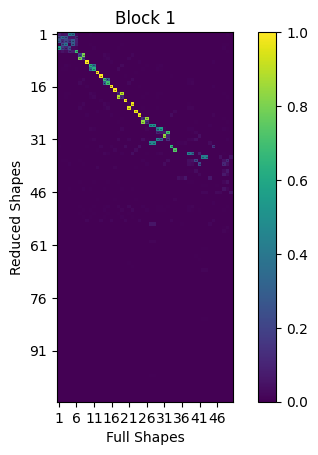

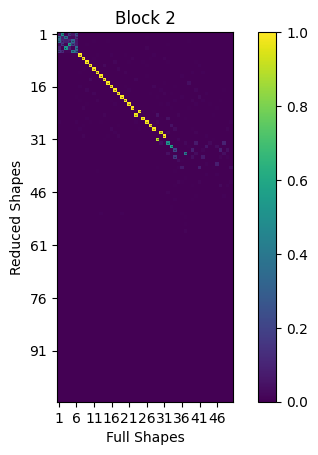

In [2]:
# Loop through each model
for i in models:
    # Load in the super element
    system,geometry,dofs = sdpy.System.from_exodus_superelement('block_{:}-cbr.nc4'.format(i),
                                                                'block_{:}-cbr.exo'.format(i))
    # Set the color of the model so they aren't all blue
    geometry.element.color=1+(i-1)*6
    
    # Compute modes of the reduced system
    cb_shapes = system.eigensolution()
    
    # Load in the eigensolution to compare against
    full_shapes = sdpy.shape.from_exodus(sdpy.Exodus('block_{:}-eig.exo'.format(i)))
    
    # Assign comments so we know which is which
    cb_shapes.comment1 = 'Reduced Block {:}'.format(i)
    full_shapes.comment1 = 'Full Block {:}'.format(i)
    
    # Compute shape alignment and flip shapes if necessary
    alignment = sdpy.shape.shape_alignment(cb_shapes[:full_shapes.size],full_shapes[:full_shapes.size])
    cb_shapes[:full_shapes.size] = cb_shapes[:full_shapes.size]*alignment[:,np.newaxis]
    
    # Overlay shapes
    compare_geo, compare_shapes = sdpy.shape.overlay_shapes(
        [geometry,geometry],[cb_shapes[:full_shapes.size],full_shapes],color_override=[1,7])
    compare_shapes.comment1 = 'Blue: CBR, Green: Full'
    compare_geo.plot_shape(compare_shapes,undeformed_opacity=0,deformed_opacity=0.5)
    
    # Compute a MAC
    mac = sdpy.shape.mac(cb_shapes,full_shapes)
    ax = sdpy.matrix_plot(mac,text_size=0)
    ax.set_ylabel('Reduced Shapes')
    ax.set_xlabel('Full Shapes')
    ax.set_title('Block {:}'.format(i))
    
    # Append to arrays
    systems.append(system)
    geometries.append(geometry)
    boundary_dofs.append(dofs)
    check_shapes.append(full_shapes)
    reduced_shapes.append(cb_shapes)

We see that the modes show almost perfect agreement at low frequency, and it
is only at the very high frequencies that the agreement tends to break down, which is expected of the Craig-Bampton Reduction.
Note that the rigid body modes and other repeated roots may show poor shape
correlation due to the fact that any linear combination of the repeated modes'
shapes are also valid mode shapes.

|   Error        |     Block 1 Component                                                     |   Block 2 Component                                                         |
|-----------------------|-------------------------------------|----------------------------------------------------------------------------------------------------------|
| Nearly Zero    | 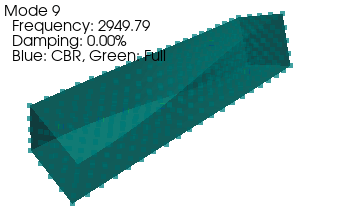 | 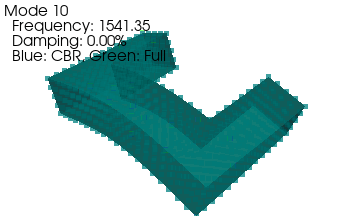| 
|   Small        | 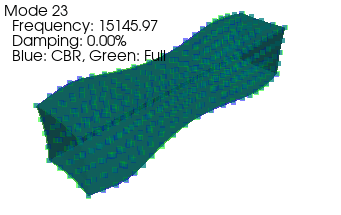 | 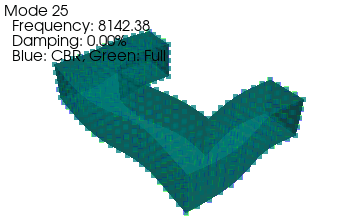 |
|  Large         | 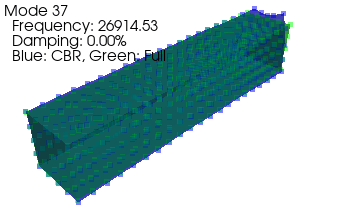 | 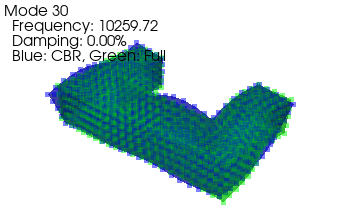| 

## Combining Component Models

With the systems loaded, we can now combine the models into a single assembly.
The model was created such that the boundary nodes are collocated, so we can
use the 
[`sdpy.system.substructure_by_position`](#api:sdynpy.System.substructure_by_position)
function to combine the nodes.  The function takes a list of systems to combine
and a list of geometries to use to identify collocated nodes.  After we perform
the substructuring, we can compute the eigensolution and plot the assembled shapes.


In [3]:
combined_system, combined_geometry = sdpy.system.substructure_by_position(systems, geometries)
combined_shapes = combined_system.eigensolution()
combined_geometry.plot_shape(combined_shapes);

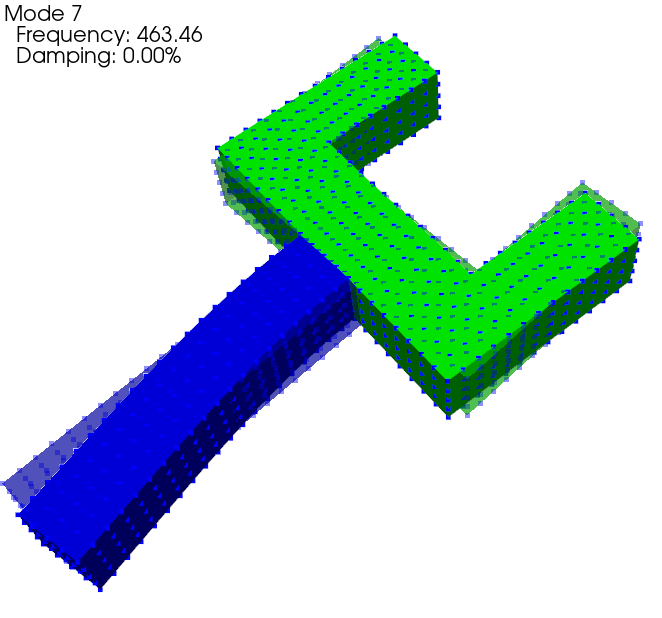

We can see by the mode shape that the system was assembled successfully as all
the nodes at the boundary surface stay together.

We will now compare the substructured modes to the truth modes from the
full system eigensolution.  We can load in the Exodus file and extract the
geometry and shapes.

In [4]:
# Load in the data to compare to
exo = sdpy.Exodus('block_all-eig.exo')
full_geometry = sdpy.geometry.from_exodus(exo)
full_shapes = sdpy.shape.from_exodus(exo)

Note however that we cannot directly compare the shapes.  In the
[`sdpy.system.substructure_by_position`](#api:sdynpy.System.substructure_by_position)
function, the node IDs are offset so there are no conflicts between substructures
that may have the same node numbers.  We therefore need to figure out the mapping
between the substructured node IDs and the truth node IDs.

Since the nodes coordinates are identical between the substructured and truth
models, we can use the node positions to determine the mapping.  We will let the
original nodes be the nodes from the truth model, and we will select the 
substructured nodes that correspond to the original nodes using the
[`by_position`](#api:sdynpy.NodeArray.by_position)
method of the [`NodeArray`](#api:sdynpy.NodeArray)
object.  We can then construct an [`id_map`](#api:sdynpy.id_map)
object using these nodes, which many correlation functions in SDynPy accept
to map nodes that have differing IDs.

In [5]:
# Map the shapes back to the original nodes because the substructuring has
# automatically renamed them to avoid conflicts
original_nodes = full_geometry.node.id
# Get the closest node to the original node
substructured_nodes = combined_geometry.node.by_position(full_geometry.node.coordinate).id
# Create an ID map
id_map = sdpy.id_map(original_nodes,substructured_nodes)

Now that the node map between the substructured model and truth model has been
defined, we can use it to perform correlations.  We will compute the MAC matrix
between the substructured shapes and the truth shapes to identify shape
correlations, and then we will compute the frequency differences and print it
to a table.  Note that the node map is passed as an argument to the
[`mac`](#api:sdynpy.core.sdynpy_shape.mac) function, which informs the
functions which nodes to compare between the two sets of shapes.

  Mode  Freq 1 (Hz)  Freq 2 (Hz)  Freq Error  MAC
     1       463.46       463.46        0.0%  100
     2       585.96       585.95        0.0%  100
     3       750.96       750.96        0.0%  100
     4       834.17       834.17        0.0%  100
     5      1368.52      1368.49        0.0%  100
     6      1434.50      1434.50        0.0%  100
     7      1458.51      1458.50        0.0%  100
     8      1665.30      1665.14        0.0%  100
     9      1727.18      1727.17        0.0%  100
    10      2021.07      2021.03        0.0%  100
    11      2767.00      2766.90        0.0%  100
    12      3140.80      3138.37        0.1%  100
    13      3432.48      3432.29        0.0%  100
    14      3767.55      3765.91        0.0%  100
    15      3871.50      3870.86        0.0%  100
    16      4063.53      4062.56        0.0%  100
    17      4251.80      4250.85        0.0%  100
    18      4312.29      4312.22        0.0%  100
    19      4319.99      4319.28        0.0%  100


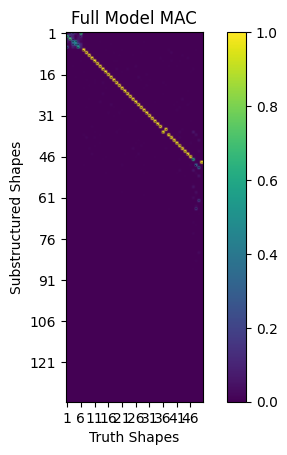

In [6]:
# Compute MAC matrix
mac = sdpy.shape.mac(combined_shapes,full_shapes,id_map)
ax = sdpy.matrix_plot(mac,text_size=0)
ax.set_ylabel('Substructured Shapes')
ax.set_xlabel('Truth Shapes')
ax.set_title('Full Model MAC')

# Print mode table
substructure_indices,truth_indices = np.where(mac[6:,6:] > 0.7)
print(sdpy.shape.shape_comparison_table(combined_shapes[substructure_indices+6],
                                        full_shapes[truth_indices+6],
                                        damping_format = None,node_id_map=id_map))

The results are very good.  MAC values between the truth and substructure shapes
are generally above 95, and only one mode has a frequency error of more than 1%,
with several having a frequency error of less than 0.1%.  

Finally, we can overlay the substructure shapes.  We again compute alignments
to ensure the shapes are not overlaid out of phase with one another.  We can
pass the node map to the [`shape_alignment`](#api:sdynpy.ShapeArray.shape_alignment)
static method to inform which nodes should be compared between the two sets of
shapes.  The shapes are then multiplied by the alignment vector to flip their
signs if necessary, and finally the shapes can be overlaid and plotted,
again using the
[`ShapeArray.overlay_shapes`](#api:sdynpy.ShapeArray.overlay_shapes)
static method.  It isn't until the 31st mode shape that there is a visible
difference in the mode shape, so the substructuring can be considered very
accurate.

In [7]:
# Align shapes
alignment = sdpy.shape.shape_alignment(combined_shapes[substructure_indices+6],full_shapes[truth_indices+6],id_map)
combined_shapes[substructure_indices+6] = combined_shapes[substructure_indices+6]*alignment[:,np.newaxis]
# Overlay shapes
compare_geo, compare_shapes = sdpy.shape.overlay_shapes(
    [combined_geometry,full_geometry],[combined_shapes[substructure_indices+6],full_shapes[truth_indices+6]],color_override=[1,7])
compare_shapes.comment1 = 'Blue: CB Substructured, Green: Truth'
compare_geo.plot_shape(compare_shapes,undeformed_opacity=0,deformed_opacity=0.5);

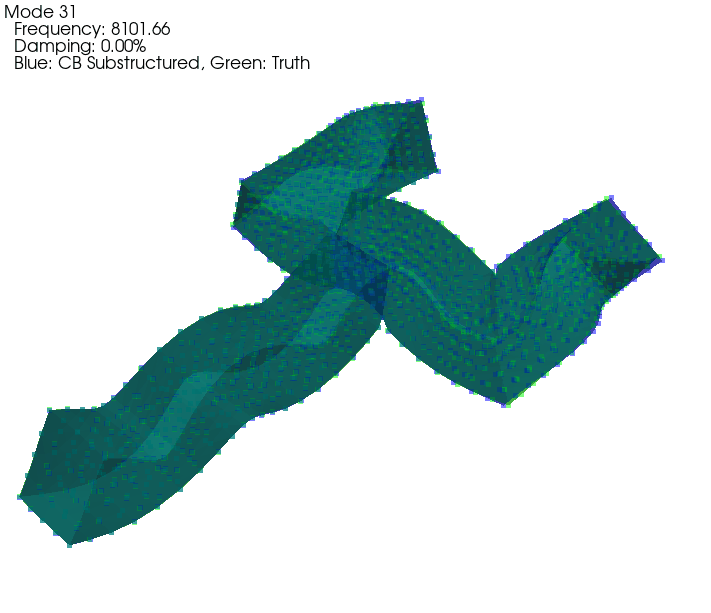



## Summary

This example has demonstrated how Craig-Bampton superelement and transformation
files from Sierra/SD can be loaded into SDynPy as a system object and then used
for substructuring.  The results were compared against truth data from an
eigensolution of the full system matrices, and very good agreement was obtained.